# Atividade Prática — Aula 5: Visualização de Dados para Decisões com Matplotlib e Seaborn

Esta atividade foi construída com base nos slides da Aula 5, cujo foco é transformar dados limpos em **gráficos que apoiem decisões**, e não em imagens decorativas. A aula reforça que o bom gráfico reduz esforço cognitivo, responde uma pergunta de negócio e precisa ser claro, comparável, simples e honesto. fileciteturn6file0

## Regras desta atividade
- Você deve **construir os códigos**.
- O notebook orienta os passos, mas não entrega a solução pronta.
- Após cada gráfico principal, escreva uma **interpretação curta** em markdown.
- O gráfico deve ser tratado como parte do seu portfólio: título, unidade, ordenação e mensagem importam. fileciteturn6file0

## Dataset da atividade
Arquivo: `vendas_brasil_clean_aula5.csv`


## 1. Preparação do ambiente

Importe as bibliotecas necessárias para trabalhar com:
- manipulação de dados
- gráficos com Matplotlib
- gráficos com Seaborn

**Sugestão:**
- `pandas`
- `matplotlib.pyplot`
- `seaborn`


In [1]:
# Escreva aqui suas importações
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Leitura da base

Leia o arquivo `vendas_brasil_clean_aula5.csv` em um DataFrame chamado `df`.

Depois:
1. exiba as primeiras linhas
2. verifique o tamanho da base
3. confira os tipos das colunas
4. observe quais variáveis podem ser usadas para:
   - comparação
   - tendência
   - distribuição
   - relação entre métricas


In [2]:
# Leia o CSV e faça uma inspeção inicial

df = pd.read_csv('vendas_brasil_clean_aula5.csv')
df.head()

,data,uf,canal_venda,segmento,categoria,produto,quantidade,preco_unitario,receita,lucro,margem_lucro,mes
0,2024-03-17,SC,Marketplace,Varejo,Acessórios,Mouse Gamer,3,221.45,664.35,-110.6595,-0.166568,2024-03
1,2024-08-28,BA,Online,Varejo,Acessórios,Mouse Gamer,3,195.52,586.56,232.5600,0.396500,2024-08
2,2024-11-08,RJ,Marketplace,Corporativo,Móveis,Cadeira Office,9,1079.28,9713.52,3416.6700,0.351700,2024-11
3,2024-08-21,RJ,Online,Varejo,Acessórios,Headset Pro,3,309.43,928.29,416.8800,0.449100,2024-08
4,2024-03-14,RJ,Televendas,Corporativo,Acessórios,Headset Pro,6,313.42,1880.52,778.5600,0.414000,2024-03


In [3]:
df.shape

(480, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   data            480 non-null    object 
 1   uf              480 non-null    object 
 2   canal_venda     480 non-null    object 
 3   segmento        480 non-null    object 
 4   categoria       480 non-null    object 
 5   produto         480 non-null    object 
 6   quantidade      480 non-null    int64  
 7   preco_unitario  480 non-null    float64
 8   receita         480 non-null    float64
 9   lucro           480 non-null    float64
 10  margem_lucro    480 non-null    float64
 11  mes             480 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 45.1+ KB


Comparação: canal_venda, segmento, categoria, produto
Tendencia: mes, receita, margem_lucro, lucro, preço unitario
Distruibuição: receita, margem_lucro, lucro, preço unitario, quantidade

## 3. Traduzindo a pergunta em gráfico

A aula destaca que a escolha do gráfico nunca é aleatória: a pergunta define a visualização. fileciteturn6file0

### Tarefa
Preencha em markdown pelo menos 4 exemplos no formato:

- **Pergunta do gestor:** ...
- **Variáveis (Pandas):** ...
- **Tipo de gráfico:** ...
- **Biblioteca sugerida:** ...

Use como referência a matriz mostrada nos slides:
- evolução no tempo → linha
- ranking/comparação entre grupos → barras
- variabilidade e outliers → boxplot
- correlação entre duas métricas → scatter


 * 1- Como a margem de lucro varia por mes - linha
 * 2 - qual canal de venda tem maior receita - barras
 * 3 - correlação entre receita e lucro - scatter

## 4. Gráfico de barras horizontais — Qual canal gera mais caixa?

A missão prática do slide pede responder: **qual canal gera mais caixa?** fileciteturn6file0

### Tarefa
1. Agrupe a receita por `canal_venda`
2. Ordene os valores
3. Gere um gráfico de **barras horizontais**
4. Use rótulos e título claros
5. Certifique-se de que a visualização esteja limpa e fácil de ler

### Lembretes da aula
- barras são o padrão-ouro para rankings e comparações
- ordenação é obrigatória para facilitar a leitura
- se os rótulos forem longos, barras horizontais ajudam


In [9]:
# Construa aqui o gráfico de barras horizontais por canal_venda

agg_receita = df.groupby('canal_venda')['receita'].sum().sort_values(ascending=False)
agg_receita

,receita
canal_venda,
Online,909140.056
Marketplace,793477.270
Televendas,660836.370
Loja Física,647485.176


Text(0, 0.5, 'Canal de Venda')

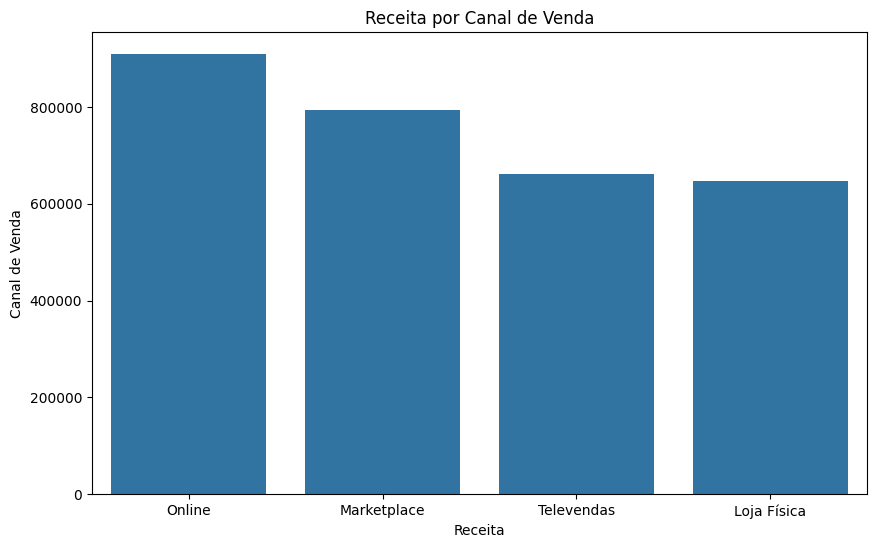

In [11]:
plt.figure(figsize=(10,6))
plt.title('Receita por Canal de Venda')
grafico_receita = sns.barplot(agg_receita)
grafico_receita.set_xlabel('Receita')
grafico_receita.set_ylabel('Canal de Venda')

### O canal online tem o maior número de receitas da empresa, enquanto a loja física tem o menor faturamento. Deve-se investir em marketplace e televendas, pois são canais com potencial para crescimento rápido, assim como o online

### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- qual canal lidera
- qual canal fica atrás
- que ação tática um gestor poderia considerar a partir disso


## 5. Gráfico de linha — Como é a sazonalidade ao longo dos meses?

Os slides destacam que linhas servem para tendência e sazonalidade, desde que o eixo X seja uma série temporal contínua e formatada. fileciteturn6file0

### Tarefa
1. Agrupe a `receita` por `mes`
2. Gere um gráfico de linha temporal
3. Remova ruídos visuais desnecessários
4. Use um título que diga **o que aconteceu**, não apenas o nome das colunas

### Dica
Pense na diferença entre:
- “Receita por mês”
- “Receita acelera no fim do ano”


<Axes: title={'center': 'Receita por Mês'}, xlabel='Mês', ylabel='Receita'>

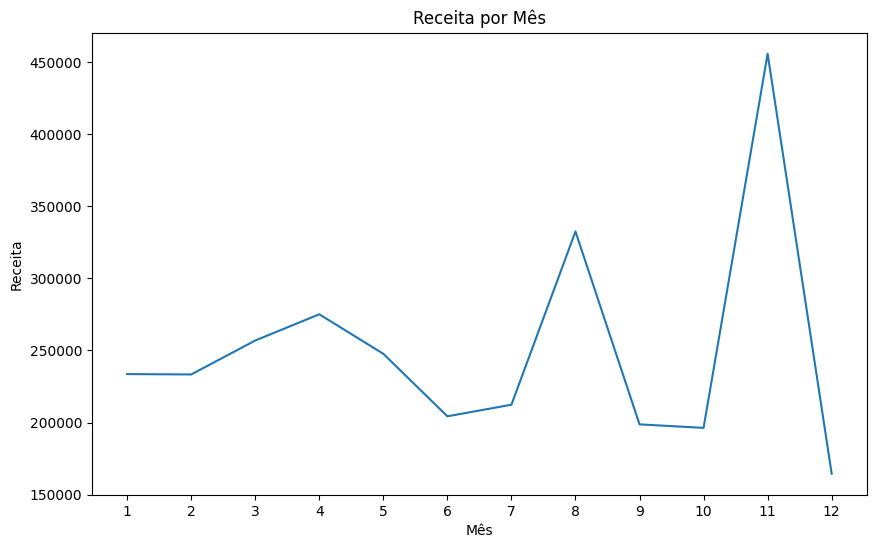

In [24]:
# Construa aqui o gráfico de linha temporal da receita por mês
df['mes'] = pd.to_datetime(df['data']).dt.month
receita_mes = df.groupby('mes')['receita'].sum()

plt.figure(figsize=(10,6))
plt.title('Receita por Mês')
plt.xlabel('Mês')
plt.ylabel('Receita')
plt.xticks(range(1,13))
grafico_receita_mes = sns.lineplot(data=receita_mes)
grafico_receita_mes


### Existe uma sazonalidade nos meses de agosto e novembro, nas épocas de festividade e férias e bônus salarial, onde ocorreu os maiores picos.

### Insight obrigatório
Responda:
- existe sazonalidade?
- há meses de pico?
- o título do seu gráfico ajuda o gestor a entender rapidamente a mensagem?


## 6. Boxplot — A margem oscila por segmento?

Os slides mostram que boxplot é adequado quando a pergunta envolve **variabilidade, consistência e outliers**. fileciteturn6file0

### Tarefa
1. Use `segmento` no eixo categórico
2. Use `margem_lucro` como variável numérica
3. Gere um **boxplot** com Seaborn
4. Observe dispersão, mediana e possíveis outliers

### Perguntas
- Qual segmento parece mais estável?
- Existe maior risco ou variabilidade em algum deles?
- Há outliers relevantes?


<Axes: title={'center': 'Margem de Lucro por Segmento'}, xlabel='Segmento', ylabel='Margem de Lucro'>

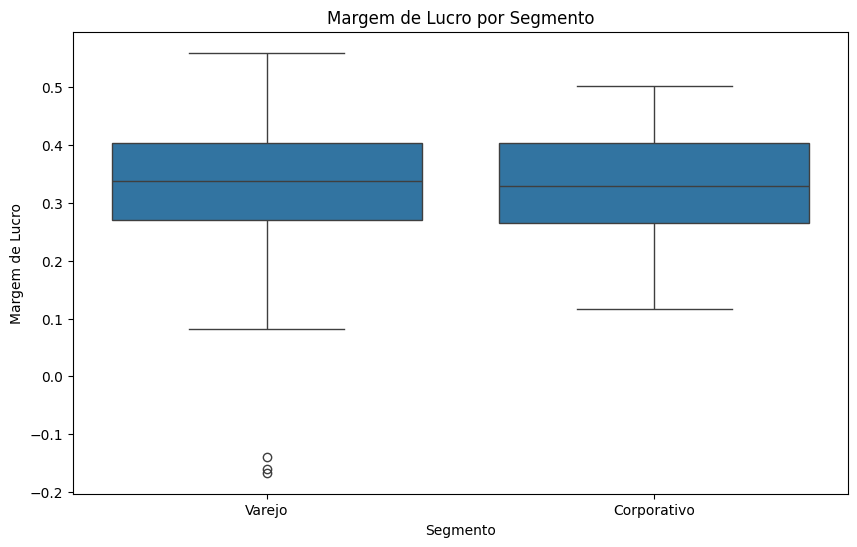

In [26]:
# Construa aqui o boxplot de margem_lucro por segmento

plt.figure(figsize=(10,6))
plt.title('Margem de Lucro por Segmento')
plt.xlabel('Segmento')
plt.ylabel('Margem de Lucro')

grafico_lucro_segmento = sns.boxplot(data=df, x='segmento', y='margem_lucro')
grafico_lucro_segmento

### Há mais inconsistências no Varejo, onde se tem itens com margem de lucro negativa, o que seria um outlier. Além disso, a distribuição da margem é maior no varejo, o que mostra um segmento imprevisível, que pode variar drasticamente.O corporativo possui uma distribuição mais equilibrada, o que mostra um segmento mais seguro e com menos riscos.

### Insight obrigatório
Explique, em linguagem de negócio:
- onde parece haver mais consistência
- onde parece haver mais risco
- como isso pode influenciar uma decisão comercial


## 7. Scatter plot — Produto que fatura muito, dá lucro?

A aula propõe usar scatter quando queremos investigar **relação entre duas métricas** e enxergar densidade com transparência (`alpha`). fileciteturn6file0

### Tarefa
1. Gere um scatter com:
   - eixo X: `receita`
   - eixo Y: `lucro`
2. Use transparência para melhorar a leitura
3. Observe se existe correlação
4. Procure anomalias: pontos com alta receita e lucro ruim, por exemplo

### Perguntas
- A relação entre receita e lucro parece positiva?
- Existem exceções preocupantes?


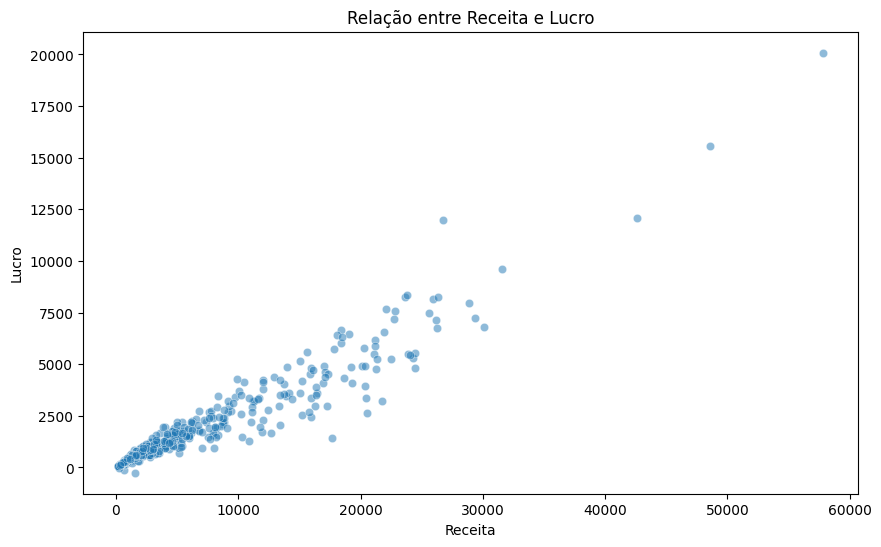

In [27]:
# Construa aqui o scatter plot entre receita e lucro

plt.figure(figsize=(10,6))
plt.title('Relação entre Receita e Lucro')
plt.xlabel('Receita')
plt.ylabel('Lucro')

grafico_receita_lucro = sns.scatterplot(data=df, x='receita', y='lucro', alpha=0.5)


### A relação entre as duas variáveis existe e é mto grande. Quanto maior o valor da receita, maior o valor do lucro. Há poucas anomalias e não são preocupantes. Após esse gráfico, o gestor deve focar em aumentar a receita de seus produtos

### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- se existe correlação visual
- se há anomalias
- que tipo de investigação o gestor deveria fazer depois desse gráfico


## 8. Comunicação vs. decoração

A aula mostra que visualização não é estética pela estética. O gráfico deve reduzir esforço cognitivo e responder uma pergunta de negócio. fileciteturn6file0

### Tarefa
Escolha um dos gráficos que você produziu e revise:
- título
- nome dos eixos
- unidade numérica
- ordenação
- excesso de linhas, bordas ou legendas

Depois escreva:
1. O que você removeu?
2. O gráfico ficou mais fácil de interpretar?


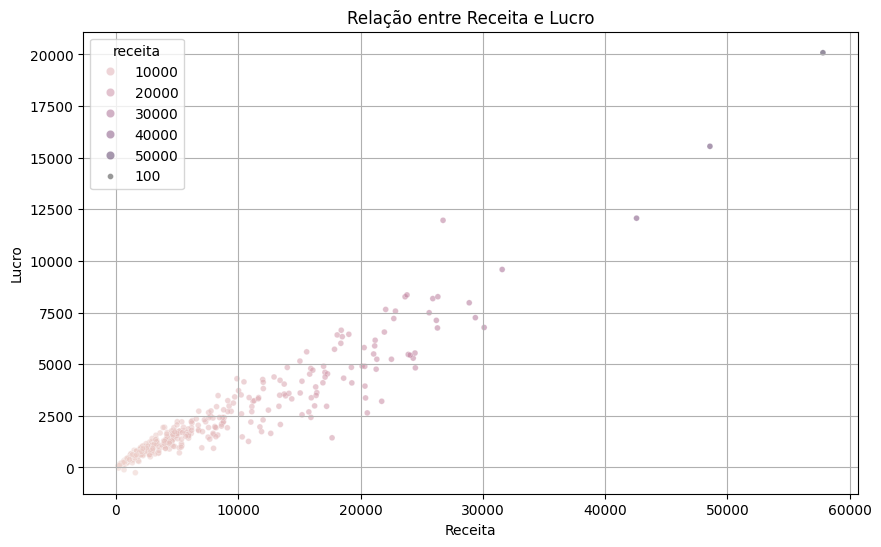

In [38]:
# Refaça aqui um dos gráficos com foco em simplicidade e clareza
plt.figure(figsize=(10,6))
plt.title('Relação entre Receita e Lucro')
plt.xlabel('Receita')
plt.ylabel('Lucro')
plt.grid(True)

grafico_receita_lucro = sns.scatterplot(data=df, x='receita', y='lucro', alpha=0.5, hue='receita',size=100)


## 9. Comparabilidade e honestidade

Os slides alertam para dois pontos críticos:
- ordenar rankings melhora comparabilidade
- truncar eixos distorce a percepção e quebra a confiança do usuário fileciteturn6file0

### Tarefa
Responda em markdown:

1. Por que ordenar barras é importante?
2. Por que truncar o eixo Y pode ser antiético ou enganoso?
3. Em que tipo de gráfico a base zero é especialmente importante?


## 10. Galeria dos vilões

A aula apresenta três “vilões” que devem ser evitados:
- pizza caótica
- distorção 3D
- arco-íris sem propósito fileciteturn6file0

### Tarefa
Explique, em markdown:
1. Por que gráfico de pizza com muitas categorias costuma falhar?
2. Por que o 3D atrapalha comparações?
3. Por que usar muitas cores sem intenção gera confusão cognitiva?


## 11. Storytelling — O gráfico não fala sozinho

Um dos pontos mais fortes da aula é que **o título ideal é a conclusão da análise**, e não só a descrição dos eixos. fileciteturn6file0

### Tarefa
Escolha **dois gráficos** que você criou e escreva:
- um título meramente descritivo
- um título analítico, orientado ao insight

Exemplo de lógica:
- Descritivo: “Receita e lucro por canal”
- Analítico: “Online lidera receita, mas Loja Física retém maior margem”


## 12. Missão prática — Case Varejo Brasil

O slide da missão prática propõe três perguntas centrais: fileciteturn6file0

1. Qual canal gera mais caixa?
2. Como é nossa sazonalidade ao longo dos meses?
3. Nosso mix corporativo é mais estável que o varejo?

### Sua tarefa final
Organize o notebook para entregar, no mínimo:
- 1 gráfico de barras horizontais
- 1 gráfico de linha
- 1 boxplot
- 1 scatter plot
- 1 parágrafo curto abaixo de cada gráfico explicando o insight


## 13. Checklist do analista profissional

Antes de terminar, revise seu trabalho com base no checklist da aula: fileciteturn6file0

- O gráfico responde claramente à pergunta original?
- Você removeu linhas, bordas e legendas que não agregam?
- Os eixos estão honestos e não distorcem a realidade?
- As cores foram usadas com intenção?
- Há um pequeno texto explicando o insight?

### Tarefa
Responda esse checklist em markdown, item por item.


## 14. Desafio extra (opcional)

Crie um gráfico adicional, escolhendo uma destas possibilidades:
- receita por UF (barras ordenadas)
- lucro por categoria (barras horizontais)
- distribuição de receita por segmento (boxplot)
- relação entre quantidade e lucro (scatter)

Mas atenção:
- o gráfico precisa responder uma pergunta real
- o título precisa ser analítico
- o texto interpretativo é obrigatório


In [ ]:
# Desafio extra opcional


## 15. Entrega esperada

Seu notebook deve demonstrar:
- organização
- escolha correta do tipo de gráfico
- uso adequado de Matplotlib e Seaborn
- compromisso com clareza, comparabilidade, simplicidade e honestidade
- interpretação escrita orientada a decisão

### Mensagem principal da aula
Não basta plotar. É preciso **comunicar o sinal no meio do ruído**. fileciteturn6file0
